In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
cData = pd.read_csv(r"C:\Users\DELL\Downloads\Bengaluru_House_Data.csv")
cData.shape

(13320, 9)

In [7]:
cData = cData.dropna()

In [8]:
cData.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.00


In [9]:
cData = cData.drop('society', axis=1)
cData['area_type'] = cData['area_type'].replace({
    'Super built-up  Area': 'Super Built-up',
    'Built-up  Area': 'Built-up',
    'Plot  Area': 'Plot',
    'Carpet  Area': 'Carpet'
})
cData.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super Built-up,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
3,Super Built-up,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
5,Super Built-up,Ready To Move,Whitefield,2 BHK,1170,2.0,1.0,38.00
11,Plot,Ready To Move,Whitefield,4 Bedroom,2785,5.0,3.0,295.00


In [10]:
cData = pd.get_dummies(cData, columns=['area_type', 'availability'])
cData.head()

,location,size,total_sqft,bath,balcony,price,area_type_Built-up,area_type_Carpet,area_type_Plot,area_type_Super Built-up,...,availability_21-May,availability_21-Nov,availability_21-Oct,availability_21-Sep,availability_22-Dec,availability_22-Jan,availability_22-Jun,availability_22-May,availability_22-Nov,availability_Ready To Move
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
5,Whitefield,2 BHK,1170,2.0,1.0,38.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
11,Whitefield,4 Bedroom,2785,5.0,3.0,295.00,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [11]:
cData.describe()

,bath,balcony,price
count,7496.000000,7496.000000,7496.000000
mean,2.458378,1.629936,96.857122
std,0.881128,0.780127,105.382490
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,49.500000
50%,2.000000,2.000000,69.755000
75%,3.000000,2.000000,105.000000
max,9.000000,3.000000,2700.000000


In [12]:
cData.dtypes

location                       object
size                           object
total_sqft                     object
bath                          float64
balcony                       float64
                               ...   
availability_22-Jan              bool
availability_22-Jun              bool
availability_22-May              bool
availability_22-Nov              bool
availability_Ready To Move       bool
Length: 84, dtype: object

In [13]:
sqftIsDigit = pd.DataFrame(cData.total_sqft.astype(str).str.isdigit())
cData[sqftIsDigit['total_sqft'] == False]

,location,size,total_sqft,bath,balcony,price,area_type_Built-up,area_type_Carpet,area_type_Plot,area_type_Super Built-up,...,availability_21-May,availability_21-Nov,availability_21-Oct,availability_21-Sep,availability_22-Dec,availability_22-Jan,availability_22-Jun,availability_22-May,availability_22-Nov,availability_Ready To Move
30,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
44,Kanakpura Road,2 BHK,1330.74,2.0,2.0,91.790,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
122,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
142,Kasavanhalli,3 BHK,1563.05,3.0,1.0,105.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12990,Talaghattapura,3 BHK,1804 - 2273,3.0,0.0,122.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
13059,Harlur,2 BHK,1200 - 1470,2.0,0.0,72.760,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
13123,9th Phase JP Nagar,2 BHK,1331.95,2.0,2.0,69.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
13265,Hoodi,2 BHK,1133 - 1384,2.0,0.0,59.135,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [14]:
cData = cData.replace('?', np.nan)
cData[sqftIsDigit['total_sqft'] == False]

,location,size,total_sqft,bath,balcony,price,area_type_Built-up,area_type_Carpet,area_type_Plot,area_type_Super Built-up,...,availability_21-May,availability_21-Nov,availability_21-Oct,availability_21-Sep,availability_22-Dec,availability_22-Jan,availability_22-Jun,availability_22-May,availability_22-Nov,availability_Ready To Move
30,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
44,Kanakpura Road,2 BHK,1330.74,2.0,2.0,91.790,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
122,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
142,Kasavanhalli,3 BHK,1563.05,3.0,1.0,105.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12990,Talaghattapura,3 BHK,1804 - 2273,3.0,0.0,122.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
13059,Harlur,2 BHK,1200 - 1470,2.0,0.0,72.760,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
13123,9th Phase JP Nagar,2 BHK,1331.95,2.0,2.0,69.000,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
13265,Hoodi,2 BHK,1133 - 1384,2.0,0.0,59.135,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [11]:
cData['price'] = cData['price'].astype('float64')

In [15]:
cData['price'].median()

69.755

In [16]:
medianFiller = lambda x: x.fillna(x.median()) if x.dtype != 'object' else x

cData = cData.apply(medianFiller, axis=0)
cData['total_sqft'] = pd.to_numeric(cData['total_sqft'], errors='coerce')

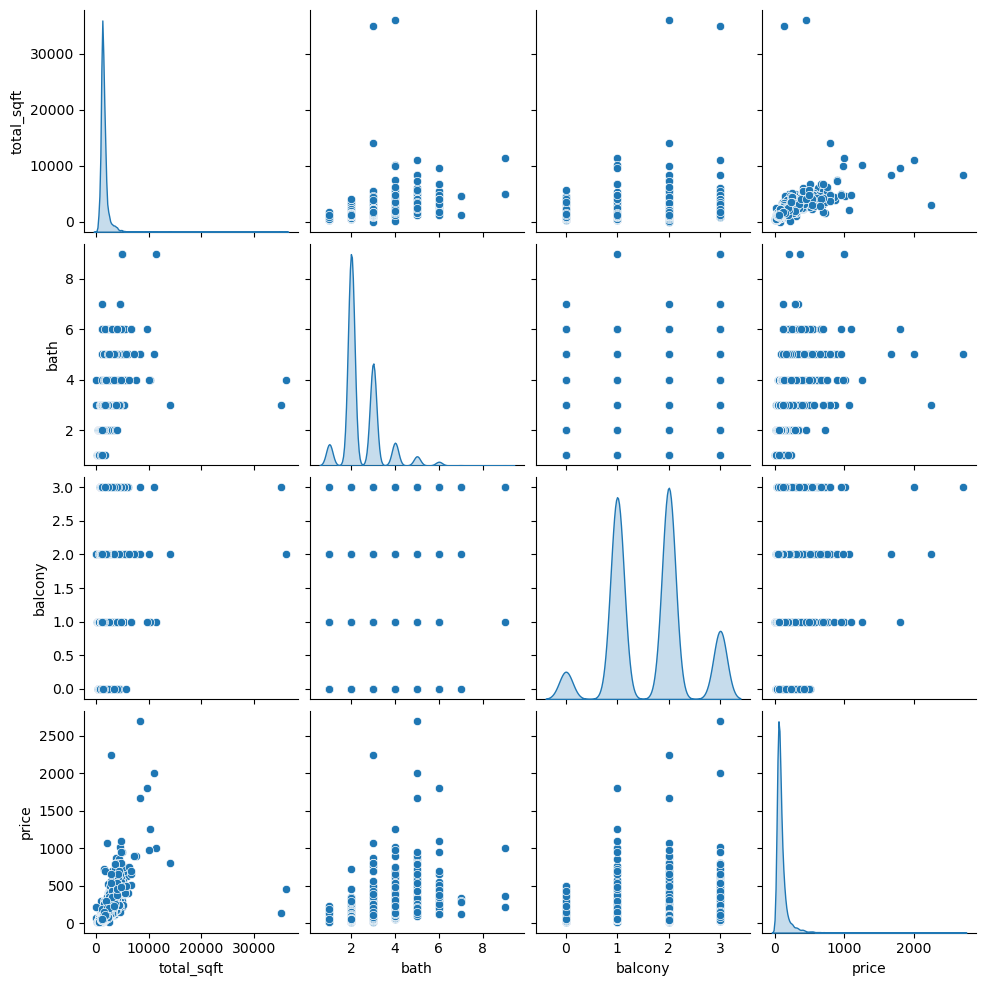

In [17]:
cData_attr = cData[['total_sqft', 'bath', 'balcony', 'price']]
sns.pairplot(cData_attr, diag_kind='kde')
plt.show()

In [18]:
X = cData.drop(['price'], axis=1)
y = cData[['price']]

In [19]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=1)

In [20]:
X = cData[['total_sqft']]
y = cData['price']

In [21]:
def convert_sqft(x):
    try:
        if '-' in str(x):
            nums = x.split('-')
            return (float(nums[0]) + float(nums[1])) / 2
        return float(x)
    except:
        return np.nan

cData['total_sqft'] = cData['total_sqft'].apply(convert_sqft)

cData = cData[['total_sqft', 'price']].dropna()

from sklearn.model_selection import train_test_split

X = cData[['total_sqft']]
y = cData['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

from sklearn.linear_model import LinearRegression

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = regression_model.predict(X_test)

In [23]:
score = regression_model.score(X_test, y_test)
print("Accuracy:", score)

Accuracy: 0.08209482027142079


In [24]:
print("Slope:", regression_model.coef_)
print("Intercept:", regression_model.intercept_)

Slope: [0.08748364]
Intercept: -34.55014422886795


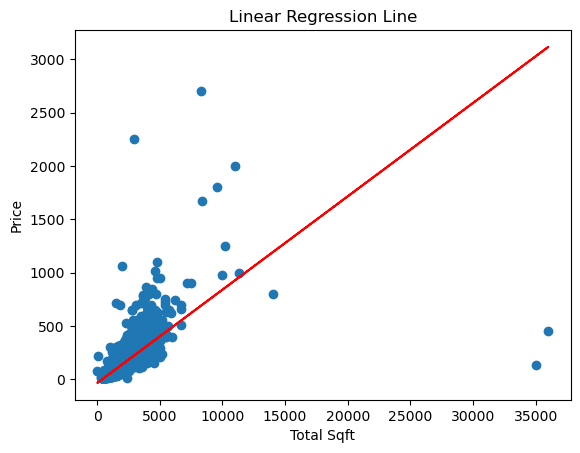

In [25]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, regression_model.predict(X), color='red')

plt.xlabel("Total Sqft")
plt.ylabel("Price")
plt.title("Linear Regression Line")

plt.show()